<a href="https://colab.research.google.com/github/sastha-06/24ADI003_ML_LAB/blob/main/24BAD106_ML_EX6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**SCENARIO 1: Decision Tree & Bagging (Diabetes Prediction)**

In this experiment, I used the Diabetes dataset to predict whether a patient has diabetes or not. I selected features like Glucose, BMI, Age, Blood Pressure, and Insulin, and used Outcome as the target variable. After splitting the dataset into training and testing data, I trained a Decision Tree model and checked its accuracy. Then, I applied the Bagging technique using multiple Decision Trees to improve the model performance and reduce overfitting. I compared the accuracies of both models using a bar graph and also used a confusion matrix to understand the predictions better. From the results, I observed that Bagging gives better accuracy and more stable results compared to a single Decision Tree model.

SASTHA JEYASRI A
24BAD106
Index(['Glucose', 'BMI', 'Age', 'BloodPressure', 'Insulin', 'Outcome'], dtype='object')
First 5 rows:
    Glucose   BMI  Age  BloodPressure  Insulin  Outcome
0      182  21.1   45             99      100        1
1      131  35.6   67             92      199        1
2      172  19.6   68             68      234        1
3       94  39.7   21            102       83        0
4      186  35.0   20            113       61        1

Missing values:
 Glucose          0
BMI              0
Age              0
BloodPressure    0
Insulin          0
Outcome          0
dtype: int64

Decision Tree Accuracy: 1.0
Bagging Accuracy: 1.0


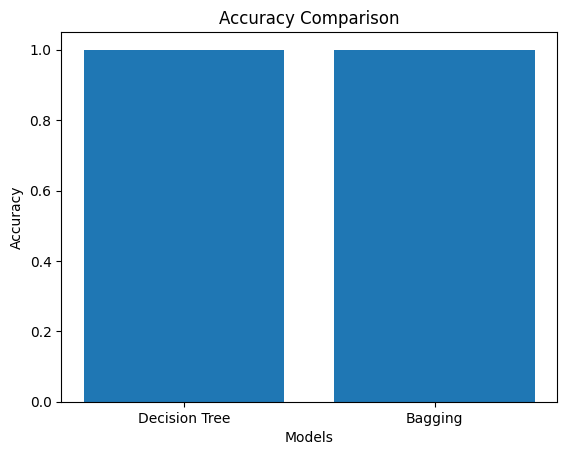

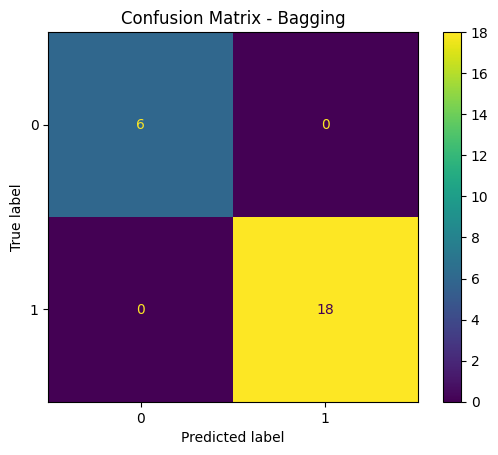

In [5]:
#from google.colab import files
#uploaded = files.upload()
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
print("SASTHA JEYASRI A\n24BAD106")

# Step 2: Load dataset
data = pd.read_csv("diabetes_bagging.csv")
print(data.columns)

# Step 3: Data inspection
print("First 5 rows:\n", data.head())
print("\nMissing values:\n", data.isnull().sum())

# Step 4: Define features and target (based on your dataset)
X = data[['Glucose', 'BMI', 'Age', 'BloodPressure', 'Insulin']]
y = data['Outcome']

# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Decision Tree model
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

# Step 7: Prediction
y_pred_dt = dt.predict(X_test)

# Step 8: Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("\nDecision Tree Accuracy:", dt_accuracy)

# Step 9: Bagging Classifier
bag = BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=10,random_state=42)
bag.fit(X_train, y_train)

# Step 10: Prediction (Bagging)
y_pred_bag = bag.predict(X_test)

# Step 11: Accuracy (Bagging)
bag_accuracy = accuracy_score(y_test, y_pred_bag)
print("Bagging Accuracy:", bag_accuracy)

# Step 12: Accuracy Comparison Graph
models = ["Decision Tree", "Bagging"]
accuracies = [dt_accuracy, bag_accuracy]

plt.figure()
plt.bar(models, accuracies)
plt.title("Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

# Step 13: Confusion Matrix (Bagging)
cm = confusion_matrix(y_test, y_pred_bag)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Bagging")
plt.show()

**SCENARIO 2: Boosting (AdaBoost & Gradient Boosting) for Customer Churn**

In this experiment, I worked with the Customer Churn dataset to predict whether a customer will leave or not. I selected features like Tenure, Monthly Charges, Contract Type, and Internet Service, and used Churn as the target variable. I handled missing values and converted categorical data into numerical form so that the model can understand it. Then, I split the dataset into training and testing sets. I trained both AdaBoost and Gradient Boosting models and compared their performance using accuracy. I also plotted the ROC curve to evaluate how well the models perform and analyzed feature importance to understand which factors affect churn the most. From the results, I observed that boosting methods give better accuracy, but sometimes very high scores can occur due to the small dataset size.

SASTHA JEYASRI A
24BAD106
Index(['Tenure', 'MonthlyCharges', 'ContractType', 'InternetService', 'Churn'], dtype='object')
First 5 rows:
    Tenure  MonthlyCharges    ContractType InternetService  Churn
0      65          105.22        Two year             NaN      0
1      17           75.19  Month-to-month             NaN      0
2      71           76.09        Two year     Fiber optic      0
3      45          107.67        Two year     Fiber optic      0
4       4           60.35        Two year             NaN      0

Missing values:
 Tenure              0
MonthlyCharges      0
ContractType        0
InternetService    43
Churn               0
dtype: int64
after handling missing value

Missing values:
 Tenure             0
MonthlyCharges     0
ContractType       0
InternetService    0
Churn              0
dtype: int64
AdaBoost Accuracy: 0.9722222222222222
Gradient Boosting Accuracy: 0.9722222222222222


/tmp/ipykernel_9635/2345769025.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['InternetService'].fillna("Unknown", inplace=True)


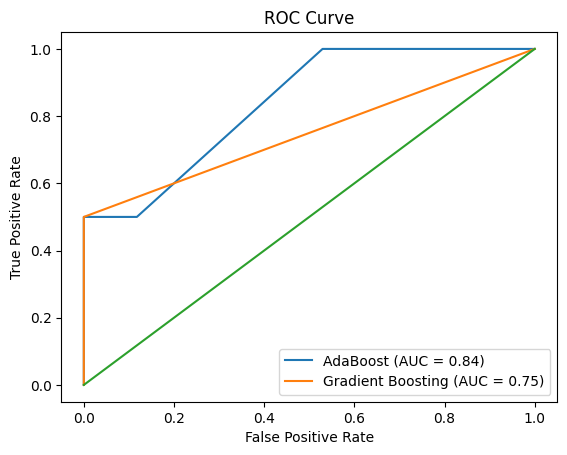

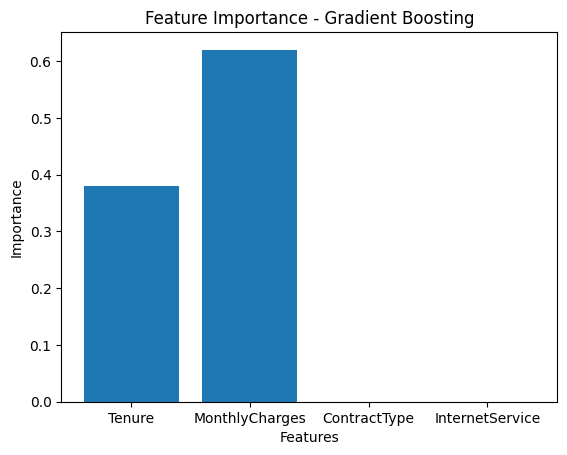

In [21]:
#from google.colab import files
#uploaded = files.upload()
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc

# Step 2: Load dataset
data = pd.read_csv("churn_boosting.csv")
print("SASTHA JEYASRI A\n24BAD106")
print(data.columns)

# Step 3: Data inspection
print("First 5 rows:\n", data.head())
print("\nMissing values:\n", data.isnull().sum())
data['InternetService'].fillna("Unknown", inplace=True)
print("after handling missing value")
print("\nMissing values:\n", data.isnull().sum())

# Step 4: Encode categorical variables
le = LabelEncoder()

data['ContractType'] = le.fit_transform(data['ContractType'])
data['InternetService'] = le.fit_transform(data['InternetService'])
data['Churn'] = le.fit_transform(data['Churn'])  # Yes=1, No=0

# Step 5: Split features and target
X = data[['Tenure', 'MonthlyCharges', 'ContractType', 'InternetService']]
y = data['Churn']

# Step 6: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42,stratify=y
)

# Step 7: Train AdaBoost
ada = AdaBoostClassifier(n_estimators=20, random_state=42)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)
ada_acc = accuracy_score(y_test, y_pred_ada)
print("AdaBoost Accuracy:", ada_acc)

# Step 8: Train Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
gb_acc = accuracy_score(y_test, y_pred_gb)
print("Gradient Boosting Accuracy:", gb_acc)

# Step 9: ROC Curve
y_prob_ada = ada.predict_proba(X_test)[:, 1]
y_prob_gb = gb.predict_proba(X_test)[:, 1]

fpr_ada, tpr_ada, _ = roc_curve(y_test, y_prob_ada)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

plt.figure()
plt.plot(fpr_ada, tpr_ada, label="AdaBoost (AUC = %.2f)" % auc(fpr_ada, tpr_ada))
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting (AUC = %.2f)" % auc(fpr_gb, tpr_gb))
plt.plot([0, 1], [0, 1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Step 10: Feature Importance (Gradient Boosting)
importances = gb.feature_importances_
features = X.columns

plt.figure()
plt.bar(features, importances)
plt.title("Feature Importance - Gradient Boosting")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()


**SCENARIO 3: Random Forest for Income Prediction**

In this experiment, I used the Adult Income dataset to predict whether a person earns more than 50K or not. I selected features like Age, EducationYears, HoursPerWeek, and Experience, and used Income as the target variable. Since Income is in categorical form, I converted it into numerical values using LabelEncoder. After handling missing values, I split the dataset into training and testing data. I trained a Random Forest model with different numbers of trees and observed how the accuracy changes. I plotted a graph between accuracy and number of trees, which showed that accuracy increases initially and then becomes stable. I also analyzed feature importance to understand which factors influence income the most. Overall, I understood that Random Forest gives high accuracy and performs better when the number of trees is chosen properly.


SASTHA JEYASRI A
24BAD106
Columns: Index(['Age', 'EducationYears', 'HoursPerWeek', 'Experience', 'Income'], dtype='object')
   Age  EducationYears  HoursPerWeek  Experience  Income
0   37              12            44          12       0
1   46              19            58          33       1
2   53              10            54          24       0
3   46              11            22           6       0
4   36              17            56           3       1

Missing values:
 Age               0
EducationYears    0
HoursPerWeek      0
Experience        0
Income            0
dtype: int64
Trees: 10, Accuracy: 0.9722222222222222
Trees: 20, Accuracy: 0.9722222222222222
Trees: 50, Accuracy: 1.0
Trees: 100, Accuracy: 1.0


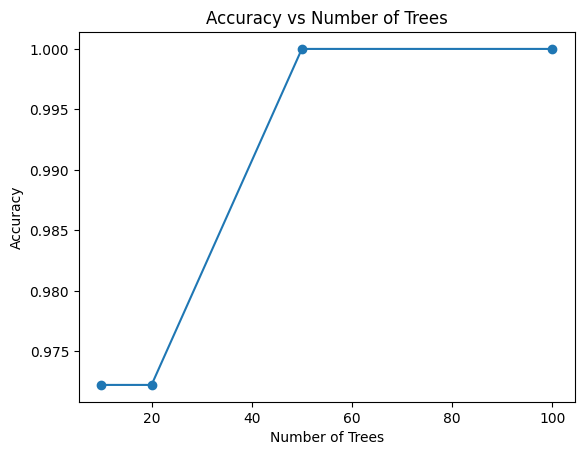

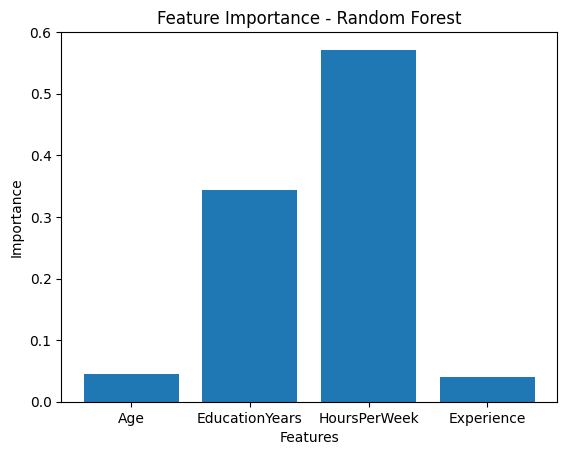

In [36]:
#from google.colab import files
#uploaded = files.upload()
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Step 2: Load dataset
data = pd.read_csv("income_random_forest.csv")
print("SASTHA JEYASRI A\n24BAD106")

# Step 3: Data inspection
print("Columns:", data.columns)
print(data.head())

# Step 4: Handle missing values (if any)
print("\nMissing values:\n", data.isnull().sum())
data.fillna(0, inplace=True)

le = LabelEncoder()
data['Income'] = le.fit_transform(data['Income'])

# Step 5: Split features and target
X = data[['Age', 'EducationYears', 'HoursPerWeek', 'Experience']]
y = data['Income']

# Step 6: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Step 7: Train Random Forest with different trees
tree_range = [10, 20, 50, 100]
accuracies = []

for n in tree_range:
    rf = RandomForestClassifier(n_estimators=n,random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"Trees: {n}, Accuracy: {acc}")

# Step 8: Accuracy vs Number of Trees graph
plt.figure()
plt.plot(tree_range, accuracies, marker='o')
plt.title("Accuracy vs Number of Trees")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.show()

# Step 9: Feature Importance
rf_final = RandomForestClassifier(n_estimators=100, random_state=42)
rf_final.fit(X_train, y_train)

importances = rf_final.feature_importances_
features = X.columns

plt.figure()
plt.bar(features, importances)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()


**SCENARIO 4: Stacking for Heart Disease Prediction**

In this experiment, I used the Heart Disease dataset to predict whether a person has heart disease or not. I selected features like Age, Cholesterol, MaxHeartRate, and RestingBP, and used HeartDisease as the target variable. Since there were no missing values, the dataset was directly used for training. I split the data into training and testing sets and trained individual models such as Logistic Regression, SVM, and Decision Tree. Then, I combined these models using a Stacking Classifier to improve performance. I compared the accuracy of all models and visualized the results using a bar chart. From the results, I observed that Decision Tree and Stacking achieved higher accuracy, while Logistic Regression gave lower accuracy. This shows that stacking helps improve prediction by combining the strengths of different models, though very high accuracy may be due to overfitting on a small dataset.


SASTHA JEYASRI A
24BAD106
Columns: Index(['Age', 'Cholesterol', 'MaxHeartRate', 'RestingBP', 'HeartDisease'], dtype='object')
   Age  Cholesterol  MaxHeartRate  RestingBP  HeartDisease
0   57          212           189        118             0
1   44          266           155        146             1
2   59          279           168        128             1
3   66          237           123        145             1
4   58          221           125        132             0

Missing values:
 Age             0
Cholesterol     0
MaxHeartRate    0
RestingBP       0
HeartDisease    0
dtype: int64
Logistic Regression Accuracy: 0.7916666666666666
SVM Accuracy: 0.875
Decision Tree Accuracy: 1.0
Stacking Accuracy: 1.0


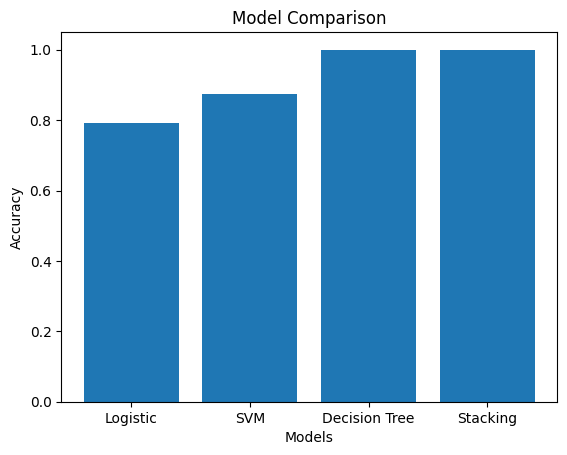

In [37]:
#from google.colab import files
#uploaded = files.upload()
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score

# Step 2: Load dataset
data = pd.read_csv("heart_stacking.csv")
print("SASTHA JEYASRI A\n24BAD106")

print("Columns:", data.columns)
print(data.head())

# Step 3: check missing values
print("\nMissing values:\n", data.isnull().sum())

# Step 4: Select features and target
X = data[['Age', 'Cholesterol', 'MaxHeartRate', 'RestingBP']]
y = data['HeartDisease']

# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 6: Train base models
lr = LogisticRegression(max_iter=1000)
svm = SVC(probability=True)
dt = DecisionTreeClassifier()

lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
dt.fit(X_train, y_train)

# Predictions
y_pred_lr = lr.predict(X_test)
y_pred_svm = svm.predict(X_test)
y_pred_dt = dt.predict(X_test)

# Accuracy
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_svm = accuracy_score(y_test, y_pred_svm)
acc_dt = accuracy_score(y_test, y_pred_dt)

print("Logistic Regression Accuracy:", acc_lr)
print("SVM Accuracy:", acc_svm)
print("Decision Tree Accuracy:", acc_dt)

# Step 7: Stacking Classifier
estimators = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('svm', SVC(probability=True)),
    ('dt', DecisionTreeClassifier())
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

stack.fit(X_train, y_train)

y_pred_stack = stack.predict(X_test)
acc_stack = accuracy_score(y_test, y_pred_stack)

print("Stacking Accuracy:", acc_stack)

# Step 8: Model comparison graph
models = ['Logistic', 'SVM', 'Decision Tree', 'Stacking']
accuracies = [acc_lr, acc_svm, acc_dt, acc_stack]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

**SCENARIO 5: SMOTE for Fraud Detection**

In this experiment, I used the Fraud Detection dataset to identify whether a transaction is fraudulent or not. I selected features like Amount, Time, Feature1, and Feature2, and used Fraud as the target variable. First, I checked the class distribution and observed that the dataset is imbalanced, with fewer fraud cases. Then, I trained a model on the original data and evaluated its performance. After that, I applied SMOTE to balance the dataset by generating synthetic samples for the minority class. I trained the model again using the balanced data and compared the performance before and after SMOTE. I also visualized the class distribution and plotted the Precision-Recall curve. From the results, I understood that SMOTE helps improve the detection of fraud cases, especially in imbalanced datasets.

SASTHA JEYASRI A
24BAD106
Columns: Index(['Amount', 'Time', 'Feature1', 'Feature2', 'Fraud'], dtype='object')
    Amount   Time  Feature1  Feature2  Fraud
0  3233.38  34595  2.157308 -0.818199      0
1  2783.63  73166  1.561511  0.955305      0
2   923.74  84417 -0.027305 -1.418366      0
3  2214.14  11139 -0.643518 -0.466037      0
4   444.75  37847  0.021272 -0.529053      0
5  2606.65  20104  0.170416  0.673181      1
6  2968.10  12330  0.677926  0.778361      0
7  3086.16  33614  0.307407 -0.100154      0
8  3175.17  44937  1.702215 -1.254289      0
9  4297.22  30683  1.196572  0.224685      0

Class Distribution:
 Fraud
0    110
1     10
Name: count, dtype: int64

Accuracy BEFORE SMOTE: 0.9166666666666666

After SMOTE Class Distribution:
 Fraud
1    88
0    88
Name: count, dtype: int64

Accuracy AFTER SMOTE: 0.75


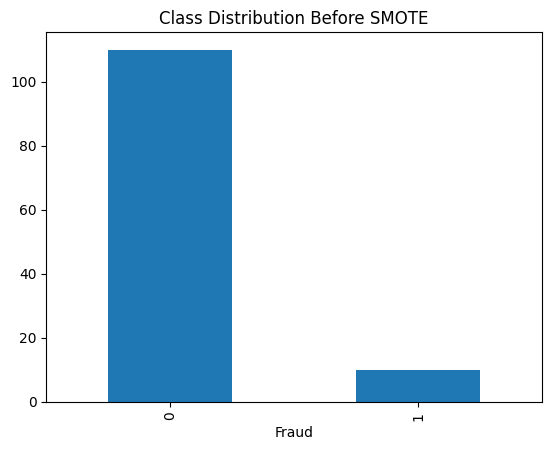

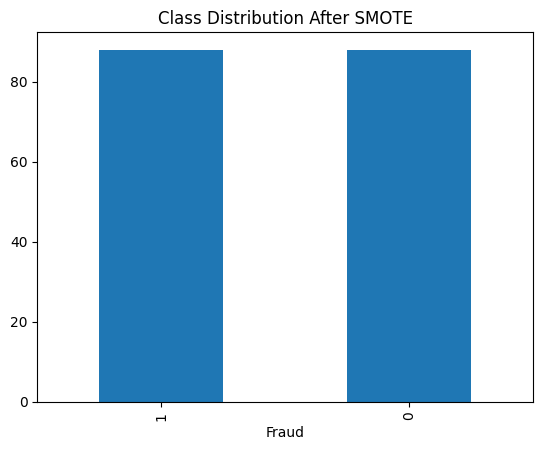

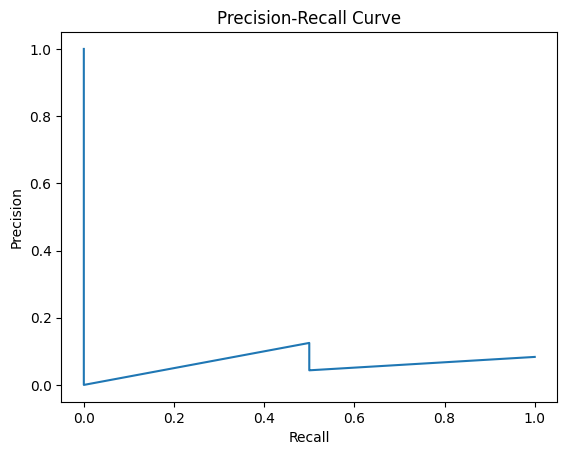

In [43]:
#from google.colab import files
#uploaded = files.upload()
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_curve

from imblearn.over_sampling import SMOTE

# Step 2: Load dataset
data = pd.read_csv("fraud_smote.csv")
print("SASTHA JEYASRI A\n24BAD106")

print("Columns:", data.columns)
print(data.head(10))

# Step 3: Check class imbalance
print("\nClass Distribution:\n", data['Fraud'].value_counts())

# Step 4: Split features and target
X = data[['Amount', 'Time', 'Feature1', 'Feature2']]
y = data['Fraud']

# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 6: Train model BEFORE SMOTE
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred_before = model.predict(X_test)
acc_before = accuracy_score(y_test, y_pred_before)

print("\nAccuracy BEFORE SMOTE:", acc_before)

# Step 7: Apply SMOTE
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("\nAfter SMOTE Class Distribution:\n", pd.Series(y_train_sm).value_counts())

# Step 8: Train model AFTER SMOTE
model.fit(X_train_sm, y_train_sm)

y_pred_after = model.predict(X_test)
acc_after = accuracy_score(y_test, y_pred_after)

print("\nAccuracy AFTER SMOTE:", acc_after)

# Step 9: Class distribution plot
plt.figure()
data['Fraud'].value_counts().plot(kind='bar')
plt.title("Class Distribution Before SMOTE")
plt.show()

plt.figure()
pd.Series(y_train_sm).value_counts().plot(kind='bar')
plt.title("Class Distribution After SMOTE")
plt.show()

# Step 10: Precision-Recall Curve
y_scores = model.predict_proba(X_test)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, y_scores)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()